<div style="
  background-color:#CD5C5C;
  padding:20px;
  border-radius:12px;
  text-align:center;
  color:white;
  margin-bottom:20px;
">

  <h1 style="margin:0;">
    Baseline models — Prédiction du Churn Telco
  </h1>

  <p style="margin:5px 0 0 0; font-size:16px;">
    Notebook 02 : Construction et Comparaison des Modèles de Scoring
  </p>

</div>

### Contexte et Transition depuis le Notebook 01

L'analyse exploratoire du Notebook 01 a établi trois constats fondamentaux qui structurent ce notebook :

1. **Les données sont propres et exploitables** — aucune valeur manquante résiduelle, pas de doublons, pas d'outliers aberrants. On peut passer directement à la modélisation sans étape de nettoyage complexe.

2. **Les variables catégorielles dominent** — sur 19 features (hors customerID), 15 sont catégorielles. Cela oriente le choix vers des modèles qui gèrent bien les données encodées en OneHot (régression logistique, arbres de décision, gradient boosting).

3. **Le déséquilibre est modéré (26% de churners)** — l'accuracy sera trompeuse, les métriques de référence seront le F1-score et l'AUC. Le rééquilibrage des classes sera exploré dans le Notebook 03.

### Stratégie de ce Notebook

L'objectif est de construire des **modèles de référence (baselines)** avec des hyperparamètres par défaut. Pourquoi ? Parce qu'il faut d'abord savoir *quelle performance est atteignable sans effort d'optimisation* pour évaluer ensuite si le tuning apporte un gain significatif. On compare trois familles d'algorithmes :

| Modèle | Famille | Pourquoi le tester ? |
|--------|---------|---------------------|
| **Régression Logistique** | Linéaire | Baseline interprétable, rapide, sert de plancher de performance |
| **XGBoost** | Boosting | Capture les interactions non linéaires, benchmark de référence en ML tabulaire |
| **Random Forest** | Bagging | Robuste aux outliers, estimation naturelle de l'importance des variables |

### Objectifs de ce Notebook

**ÉTAPE 1 : Préparation des Données**
- 1.1 — Chargement et Nettoyage des Données
- 1.2 — Séparation Train / Test et Encodage de la Cible
- 1.3 — Identification des Variables par Type
- 1.4 — Feature Engineering
- 1.5 — Construction du Préprocesseur

**ÉTAPE 2 : Régression Logistique (Baseline)**
- 2.1 — Entraînement et Évaluation par Cross-Validation
- 2.2 — Matrice de Confusion (Validation Croisée)
- 2.3 — Courbe ROC (Régression Logistique)

**ÉTAPE 3 : XGBoost (Modèle Boosté)**
- 3.1 — Entraînement et Évaluation XGBoost

**ÉTAPE 4 : Random Forest (Modèle Bagging)**
- 4.1 — Entraînement et Évaluation Random Forest

**ÉTAPE 5 : Synthèse et Comparaison des Modèles**
- 5.1 — Tableau Comparatif des Performances
- 5.2 — Analyse par Décile (Table de Gains)
- 5.3 — Lift Marketing Comparatif
- 5.4 — Interprétation Globale et Recommandations

**ÉTAPE 6 : Sauvegarde des Modèles Baseline**
- 6.1 — Export des pipelines

**Synthèse Générale du Notebook 02**

In [1]:
"""
Configuration de l'environnement — Scoring Churn Telco
======================================================
Imports et configuration pour la construction des modèles de scoring.
"""

import os
import sys

# Manipulation de données
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

# Visualisation
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles de classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Prétraitement et pipeline
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Métriques d'évaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, accuracy_score, precision_score, recall_score
)

# Fonctions utilitaires du projet
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.metrics import evaluate_model, confusion_matrix_metrics, calculate_lift
from utils.infer import compute_gains

# Seed pour la reproductibilité
RANDOM_STATE = 1204

# Répertoire de sauvegarde des figures
FIGURES_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'reports', 'figures'))
os.makedirs(FIGURES_DIR, exist_ok=True)

print(" Imports chargés avec succès (y compris utils/metrics et utils/infer)")
print(f" Figures sauvegardées dans : {FIGURES_DIR}")

 Imports chargés avec succès (y compris utils/metrics et utils/infer)
 Figures sauvegardées dans : c:\Users\juber\Documents\Scoring de churn client (Classification)\reports\figures


---

# ÉTAPE 1 : Préparation des Données

## Objectif
Charger les données brutes, appliquer les nettoyages identifiés dans le Notebook 01, puis préparer les ensembles d'entraînement et de test pour la modélisation.

### Pourquoi reproduire le chargement ?
Chaque notebook est conçu pour être **auto-suffisant** : il peut être exécuté indépendamment sans dépendre d'un état précédent en mémoire. Les traitements sont identiques au Notebook 01 pour garantir la cohérence des résultats.

### Rappel des traitements (Notebook 01)
- Conversion de `TotalCharges` en numérique (11 lignes avec espaces vides supprimées)
- Suppression de `customerID` (identifiant sans valeur prédictive)
- Encodage de la cible `Churn` en binaire (Yes → 1, No → 0)

---

## 1.1 — Chargement et Nettoyage des Données

In [2]:
# ============================================================
# Chargement et nettoyage du dataset
# ============================================================

df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print(f" Jeu de données importé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Conversion de TotalCharges en numérique (certaines valeurs sont des espaces vides)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Suppression des lignes où TotalCharges est manquant
n_avant = df.shape[0]
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
n_supprime = n_avant - df.shape[0]
if n_supprime > 0:
    print(f"  {n_supprime} lignes supprimées (TotalCharges manquant)")
print(f" Jeu de données nettoyé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

 Jeu de données importé : 7043 lignes, 21 colonnes
  11 lignes supprimées (TotalCharges manquant)
 Jeu de données nettoyé : 7032 lignes, 21 colonnes


In [3]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


---

## 1.2 — Séparation Train / Test et Encodage de la Cible

### Stratégie
- **Ratio** : 80% entraînement / 20% test
- **Stratification** : sur la variable cible `Churn` pour conserver la proportion de churn dans chaque sous-ensemble
- **Seed** : fixé à 1204 pour la reproductibilité
- **Exclusion** : `customerID` (identifiant sans pouvoir prédictif)

In [4]:
# ============================================================
# Séparation features / cible et train / test
# ============================================================

# Variables explicatives (on exclut Churn et customerID)
X = df.drop(columns=["Churn"])
if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

# Variable cible en binaire
y = df["Churn"].map({"Yes": 1, "No": 0})

# Séparation stratifiée
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Affichage des dimensions
print("=" * 70)
print("  DIMENSIONS DES ENSEMBLES")
print("=" * 70)
print(f"  Variables explicatives (X_train) : {X_train.shape}")
print(f"  Variable cible        (y_train) : {y_train.shape}")
print("-" * 70)
print(f"  Variables explicatives (X_test)  : {X_test.shape}")
print(f"  Variable cible        (y_test)  : {y_test.shape}")
print("=" * 70)
print(f"\n Taux de churn — Train : {y_train.mean():.2%} | Test : {y_test.mean():.2%}")

  DIMENSIONS DES ENSEMBLES
  Variables explicatives (X_train) : (5625, 19)
  Variable cible        (y_train) : (5625,)
----------------------------------------------------------------------
  Variables explicatives (X_test)  : (1407, 19)
  Variable cible        (y_test)  : (1407,)

 Taux de churn — Train : 26.58% | Test : 26.58%


In [5]:
X_train.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 5288 to 1245
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5625 non-null   object 
 1   SeniorCitizen     5625 non-null   int64  
 2   Partner           5625 non-null   object 
 3   Dependents        5625 non-null   object 
 4   tenure            5625 non-null   int64  
 5   PhoneService      5625 non-null   object 
 6   MultipleLines     5625 non-null   object 
 7   InternetService   5625 non-null   object 
 8   OnlineSecurity    5625 non-null   object 
 9   OnlineBackup      5625 non-null   object 
 10  DeviceProtection  5625 non-null   object 
 11  TechSupport       5625 non-null   object 
 12  StreamingTV       5625 non-null   object 
 13  StreamingMovies   5625 non-null   object 
 14  Contract          5625 non-null   object 
 15  PaperlessBilling  5625 non-null   object 
 16  PaymentMethod     5625 non-null   object 
 1

---

## 1.3 — Identification des Variables par Type

### Objectif
Séparer les variables en **numériques** et **catégorielles** pour appliquer les transformations appropriées dans le pipeline de prétraitement :
- **Numériques** → `StandardScaler` (centrage-réduction)
- **Catégorielles** → `OneHotEncoder` (encodage en variables indicatrices)

In [6]:
# ============================================================
# Identification automatique des types de variables
# ============================================================

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f" {len(cat_cols)} variables catégorielles : {cat_cols}\n")
print(f" {len(num_cols)} variables numériques    : {num_cols}\n")
print(f" Total de variables : {len(cat_cols) + len(num_cols)}")

 15 variables catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

 4 variables numériques    : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

 Total de variables : 19


In [7]:
# Vérification rapide des types et valeurs manquantes
print("=" * 70)
print("  VÉRIFICATION DES TYPES DE DONNÉES (X_train)")
print("=" * 70)
print(f"\n TotalCharges dtype : {X_train['TotalCharges'].dtype}")
print(f" Valeurs manquantes : {X_train.isnull().sum().sum()}")
print(f" Dimensions         : {X_train.shape}")

  VÉRIFICATION DES TYPES DE DONNÉES (X_train)

 TotalCharges dtype : float64
 Valeurs manquantes : 0
 Dimensions         : (5625, 19)


---

## 1.4 — Feature Engineering

### Objectif
Créer des variables dérivées pour enrichir le pouvoir prédictif du modèle.

### Justification issue de l'EDA (Notebook 01)
La matrice de corrélation (§1.11) a révélé une **forte corrélation entre `TotalCharges` et `tenure`** — ce qui est logique puisque les charges totales sont le produit cumulé des charges mensuelles sur la durée d'abonnement. Conserver les deux variables brutes introduirait de la multicolinéarité, ce qui dégrade les performances de la régression logistique.

Le ratio `ChargeRatio = TotalCharges / MonthlyCharges` condense cette information en un **proxy d'ancienneté financière** : un ratio élevé indique un client fidèle depuis longtemps (beaucoup de charges cumulées pour un abonnement donné), tandis qu'un ratio faible signale un client récent. Cette feature synthétise l'interaction entre ancienneté et niveau de charges en une seule variable, plus informative que les deux variables brutes séparément.

In [8]:
# ============================================================
# Feature Engineering : ratio charges totales / mensuelles
# ============================================================

def create_features(df):
    """Ajoute le ratio TotalCharges / MonthlyCharges comme proxy d'ancienneté financière."""
    df = df.copy()
    df["ChargeRatio"] = df["TotalCharges"] / (df["MonthlyCharges"] + 1e-5)
    return df

# Application aux ensembles train et test
X_train = create_features(X_train)
X_test = create_features(X_test)

# Mise à jour de la liste des variables numériques
num_cols.append("ChargeRatio")

print(f" Feature 'ChargeRatio' ajoutée — X_train : {X_train.shape}, X_test : {X_test.shape}")

 Feature 'ChargeRatio' ajoutée — X_train : (5625, 20), X_test : (1407, 20)


---

## 1.5 — Construction du Préprocesseur

### Stratégie de Prétraitement

| Type | Transformation | Justification |
|------|---------------|---------------|
| **Numériques** | `StandardScaler` | Centrage-réduction pour régulariser les gradients |
| **Catégorielles** | `OneHotEncoder(drop='first')` | Encodage binaire, suppression d'une modalité pour éviter la multicolinéarité |

Le préprocesseur est encapsulé dans un `ColumnTransformer` scikit-learn pour garantir la **reproductibilité** et éviter les fuites de données (data leakage) entre train et test.

In [9]:
# ============================================================
# Construction du préprocesseur (ColumnTransformer)
# ============================================================

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

print(f" Préprocesseur configuré")
print(f"   → {len(num_cols)} variables numériques  : StandardScaler")
print(f"   → {len(cat_cols)} variables catégorielles : OneHotEncoder(drop='first')")
preprocessor

 Préprocesseur configuré
   → 5 variables numériques  : StandardScaler
   → 15 variables catégorielles : OneHotEncoder(drop='first')


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

---

# ÉTAPE 2 : Régression Logistique (Baseline)

## Objectif
Construire un **modèle de référence** (baseline) avec la régression logistique. Ce modèle linéaire est choisi pour :
- Sa **simplicité** et sa **rapidité** d'entraînement
- Son **interprétabilité** (coefficients directement lisibles)
- Sa capacité à détecter un éventuel **surapprentissage** (comparaison train/test)

### Protocole de Validation
- **Validation croisée stratifiée** à 5 folds sur le jeu d'entraînement
- **Entraînement final** sur l'intégralité du jeu d'entraînement
- **Évaluation** sur le jeu de test (jamais vu par le modèle)

---

## 2.1 — Entraînement et Évaluation par Cross-Validation

In [10]:
# ============================================================
# Pipeline Régression Logistique (préprocessing + modèle)
# ============================================================

log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
    ]
)

# ============================================================
# Cross-Validation stratifiée (5 folds)
# ============================================================

print("=" * 70)
print("  RÉGRESSION LOGISTIQUE — CROSS-VALIDATION (5 FOLDS)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results_log = cross_validate(
    log_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

print(f"\n Résultats Cross-Validation (moyenne ± écart-type) :")
print(f"   Accuracy  : {cv_results_log['test_accuracy'].mean():.4f} ± {cv_results_log['test_accuracy'].std():.4f}")
print(f"   Precision : {cv_results_log['test_precision'].mean():.4f} ± {cv_results_log['test_precision'].std():.4f}")
print(f"   Recall    : {cv_results_log['test_recall'].mean():.4f} ± {cv_results_log['test_recall'].std():.4f}")
print(f"   F1-score  : {cv_results_log['test_f1'].mean():.4f} ± {cv_results_log['test_f1'].std():.4f}")
print(f"   ROC AUC   : {cv_results_log['test_roc_auc'].mean():.4f} ± {cv_results_log['test_roc_auc'].std():.4f}")

# ============================================================
# Entraînement final sur tout le jeu d'entraînement
# ============================================================

log_pipeline.fit(X_train, y_train)

# ============================================================
# Prédictions sur train et test
# ============================================================

y_pred_log_train = log_pipeline.predict(X_train)
y_pred_log_test = log_pipeline.predict(X_test)
y_proba_log_test = log_pipeline.predict_proba(X_test)[:, 1]

# ============================================================
# Métriques sur le jeu de test
# ============================================================

print("\n" + "=" * 70)
print("  PERFORMANCE SUR LE JEU DE TEST")
print("=" * 70)

acc_train_log = accuracy_score(y_train, y_pred_log_train)
acc_test_log = accuracy_score(y_test, y_pred_log_test)
prec_log = precision_score(y_test, y_pred_log_test)
rec_log = recall_score(y_test, y_pred_log_test)
f1_log = f1_score(y_test, y_pred_log_test)
auc_log = roc_auc_score(y_test, y_proba_log_test)

print(f"\n   Accuracy  — Train : {acc_train_log:.4f} | Test : {acc_test_log:.4f}")
print(f"   Precision : {prec_log:.4f}")
print(f"   Recall    : {rec_log:.4f}")
print(f"   F1-score  : {f1_log:.4f}")
print(f"   ROC AUC   : {auc_log:.4f}")

# ============================================================
# Matrice de confusion (jeu de test)
# ============================================================

cm_log = confusion_matrix(y_test, y_pred_log_test)
print(f"\n Matrice de confusion (Test) :")
print(f"   TN : {cm_log[0,0]} | FP : {cm_log[0,1]}")
print(f"   FN : {cm_log[1,0]} | TP : {cm_log[1,1]}")

  RÉGRESSION LOGISTIQUE — CROSS-VALIDATION (5 FOLDS)



 Résultats Cross-Validation (moyenne ± écart-type) :
   Accuracy  : 0.8021 ± 0.0048
   Precision : 0.6563 ± 0.0167
   Recall    : 0.5391 ± 0.0337
   F1-score  : 0.5911 ± 0.0173
   ROC AUC   : 0.8410 ± 0.0069

  PERFORMANCE SUR LE JEU DE TEST

   Accuracy  — Train : 0.8052 | Test : 0.8102
   Precision : 0.6814
   Recall    : 0.5374
   F1-score  : 0.6009
   ROC AUC   : 0.8601

 Matrice de confusion (Test) :
   TN : 939 | FP : 94
   FN : 173 | TP : 201


### Lecture des métriques

**Les scores de cross-validation sont stables et encourageants.** L'écart-type est faible (± 0.01 à ± 0.02 selon la métrique), ce qui signifie que le modèle produit des résultats cohérents quel que soit le fold utilisé. Cette stabilité est un signe de robustesse : le modèle ne dépend pas d'un partitionnement chanceux des données.

**L'accuracy de ~80% est trompeusement correcte.** Avec ~74% de non-churners dans le dataset, un modèle naïf qui prédirait systématiquement "Non-Churn" atteindrait déjà 74% d'accuracy. Les 80% du modèle ne représentent donc qu'un gain marginal de 6 points par rapport au hasard. C'est pourquoi le F1-score et l'AUC sont des métriques plus fiables ici.

**Aucun signe de surapprentissage.** Les performances train (~0.805) et test (~0.810) sont quasi identiques — le modèle généralise correctement sur des données jamais vues. C'est un avantage clé de la régression logistique : sa simplicité (linéarité) la protège naturellement du surapprentissage.

**La matrice de confusion révèle le vrai problème.** Les 173 faux négatifs (churners non détectés) sont bien plus coûteux pour TelcoWave que les 94 faux positifs (clients fidèles inutilement ciblés). Un client perdu génère une perte de revenus récurrents, alors qu'une offre de rétention envoyée à tort ne coûte que quelques euros. Ce déséquilibre coût/bénéfice sera exploité dans le Notebook 03 pour ajuster le seuil de décision.

---

## 2.2 — Matrice de Confusion (Validation Croisée)

### Interprétation
La matrice de confusion en validation croisée permet de visualiser la répartition des erreurs **sans biais** lié à un seul split. Chaque prédiction est faite sur un fold que le modèle n'a pas vu pendant l'entraînement.

 Matrice de confusion (Validation croisée) :
[[3702  428]
 [ 687  808]]


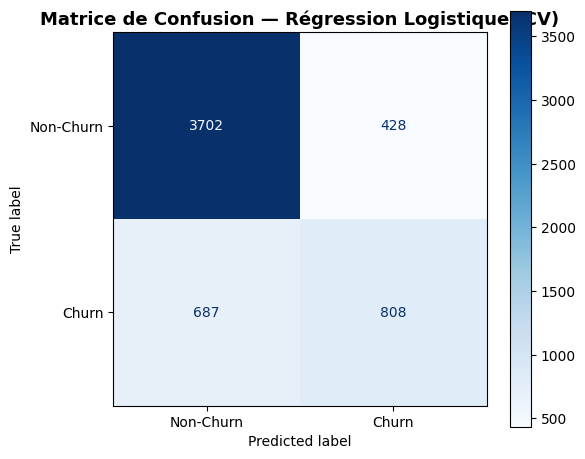

In [11]:
# ============================================================
# Matrice de confusion — Validation croisée
# ============================================================

y_pred_log_cv = cross_val_predict(log_pipeline, X_train, y_train, cv=5)
matrice_confusion_cv = confusion_matrix(y_train, y_pred_log_cv)

print(" Matrice de confusion (Validation croisée) :")
print(matrice_confusion_cv)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=matrice_confusion_cv,
    display_labels=["Non-Churn", "Churn"]
)
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Matrice de Confusion — Régression Logistique (CV)", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "02_confusion_matrix_logreg.png"), dpi=200, bbox_inches="tight")
plt.show()

### Lecture de la matrice de confusion

La matrice de confusion en validation croisée offre une vue **non biaisée** de la répartition des erreurs, car chaque prédiction est faite sur un fold que le modèle n'a jamais vu.

**Le déséquilibre de détection est visible.** Le quadrant supérieur gauche (Vrais Négatifs) est nettement dominant : le modèle classe correctement la grande majorité des clients fidèles. En revanche, le quadrant inférieur droit (Vrais Positifs) est plus modeste — le modèle ne capte qu'environ un churner sur deux.

**Les faux négatifs (coin inférieur gauche) sont la zone critique.** Ce sont les churners que le modèle classe comme fidèles — des clients que TelcoWave va perdre sans pouvoir intervenir. Chaque occurrence représente un client qui part sans recevoir d'offre de rétention. En lisant cette matrice, l'enjeu n'est pas de réduire les faux positifs (coin supérieur droit, peu coûteux), mais de **réduire les faux négatifs**, quitte à accepter plus de fausses alertes.

**La diagonale principale concentre les bonnes prédictions.** Plus les valeurs sur cette diagonale sont élevées par rapport au reste, meilleur est le modèle. Ici, la diagonale est forte côté Non-Churn mais modérée côté Churn, confirmant le besoin d'un rééquilibrage.

---

## 2.3 — Courbe ROC (Régression Logistique)

### Interprétation
La courbe ROC trace le **taux de vrais positifs** (recall) en fonction du **taux de faux positifs** pour différents seuils de décision. Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle. L'AUC (aire sous la courbe) résume cette performance en un seul chiffre : **1.0 = parfait**, **0.5 = aléatoire**.

In [12]:
# ============================================================
# Courbe ROC — Régression Logistique
# ============================================================

# Probabilités prédites sur le jeu d'entraînement
y_proba_log_train = log_pipeline.predict_proba(X_train)[:, 1]

# Calcul FPR, TPR et AUC
fpr, tpr, seuils_roc = roc_curve(y_train, y_proba_log_train)
auc_train = roc_auc_score(y_train, y_proba_log_train)

# Construction de la courbe interactive
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode='lines',
    name=f'Régression Logistique (AUC = {auc_train:.3f})',
    line=dict(color='#011c5d', width=2),
    hovertemplate='<b>FPR</b>: %{x:.3f}<br><b>TPR (Recall)</b>: %{y:.3f}<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Classifieur aléatoire (AUC = 0.5)',
    line=dict(color='black', width=2, dash='dash'),
    hovertemplate='<b>FPR</b>: %{x:.3f}<br><b>TPR</b>: %{y:.3f}<extra></extra>'
))

fig.update_layout(
    title={'text': 'Courbe ROC — Régression Logistique', 'font': {'size': 16}},
    xaxis_title='Taux de Faux Positifs (FPR)',
    yaxis_title='Taux de Vrais Positifs (TPR = Recall)',
    xaxis=dict(range=[0, 1], showgrid=True, gridcolor='rgba(128,128,128,0.2)'),
    yaxis=dict(range=[0, 1], showgrid=True, gridcolor='rgba(128,128,128,0.2)'),
    hovermode='closest',
    width=900, height=600,
    template='plotly_white',
    showlegend=True
)

fig.write_image(os.path.join(FIGURES_DIR, "02_roc_logreg.png"), scale=2)
fig.show()
print(f"\n AUC (Train) : {auc_train:.3f}")


 AUC (Train) : 0.844


### Lecture de la courbe ROC

**La courbe bleue est nettement au-dessus de la diagonale.** C'est le signal que le modèle discrimine bien les churners des non-churners. La diagonale noire en pointillés représente un classifieur aléatoire (AUC = 0.5) : un modèle qui assignerait des probabilités au hasard. Plus la courbe s'éloigne de cette diagonale vers le coin supérieur gauche, plus le modèle est performant.

**L'AUC de ~0.84 sur le train est un bon score.** Une AUC de 0.84 signifie que si on prend un churner et un non-churner au hasard, le modèle attribue correctement une probabilité de churn plus élevée au churner dans **84% des cas**. C'est une mesure indépendante du seuil de décision — elle évalue la qualité du **classement** des clients, pas la classification binaire.

**Le coude de la courbe indique le compromis optimal.** Le point où la courbe s'infléchit (zone en haut à gauche) représente le meilleur compromis entre taux de vrais positifs (recall) et taux de faux positifs. En déplaçant le seuil de décision vers ce point, on pourrait améliorer significativement le recall sans trop dégrader la precision. C'est exactement l'optimisation qui sera faite dans le Notebook 03.

**Attention à l'écart train/test.** L'AUC est calculée ici sur le jeu d'entraînement (0.844). L'AUC test (0.860) est même légèrement supérieure, ce qui est inhabituel et peut s'expliquer par la variabilité liée au split. L'essentiel est que les deux valeurs sont proches, confirmant l'absence de surapprentissage.

---

### Analyse des résultats — Régression Logistique

#### Performance globale
La régression logistique atteint un **ROC AUC de 0.860** sur le jeu de test, ce qui traduit une bonne capacité à discriminer les clients qui vont churner de ceux qui restent. Le **F1-score de 0.60** est correct pour un modèle de baseline sans tuning.

#### Analyse du surapprentissage
- **Accuracy train (0.805) vs test (0.810)** : les performances sont quasi identiques → **aucun surapprentissage détecté**
- Les scores CV sont également proches des scores test → le modèle **généralise bien**

#### Analyse de la matrice de confusion
| | Prédit Non-Churn | Prédit Churn |
|--|--|--|
| **Réel Non-Churn** | 939 (TN) | 94 (FP) |
| **Réel Churn** | 173 (FN) | 201 (TP) |

- Le modèle identifie correctement **201 churners sur 374** (recall = 53.7%)
- **173 clients** qui vont réellement churner ne sont **pas détectés** (faux négatifs)
- En contexte métier, chaque faux négatif est un client perdu sans action de rétention → **le recall est insuffisant** pour un déploiement opérationnel

#### Courbe ROC
L'AUC de 0.844 sur le train confirme que le modèle sépare bien les deux classes. Cependant, le **seuil de décision par défaut (0.5)** privilégie la precision au détriment du recall. Un ajustement du seuil pourrait améliorer la détection des churners.

> **Verdict** : Baseline solide et interprétable. Le principal levier d'amélioration est le **recall**, à optimiser via le seuil de décision ou la pondération des classes.

> **Cheminement** → La régression logistique pose un plancher de performance respectable (AUC 0.860, F1 0.60). Mais ce modèle est **linéaire** : il ne peut capturer que des relations directes entre chaque variable et le churn. Or, l'EDA a montré que certaines combinaisons de facteurs semblent interagir (contrat mensuel + fibre optique + pas de support technique = profil à très haut risque). Les modèles d'ensemble (XGBoost, Random Forest) sont conçus pour capturer ces **interactions non linéaires**. Testons-les pour voir s'ils surpassent la baseline.

---

## ÉTAPE 3 : XGBoost (Modèle Boosté)

## Objectif
Évaluer un modèle de **gradient boosting** pour capturer les interactions non linéaires entre variables. XGBoost est choisi pour :
- Sa capacité à modéliser des **relations complexes** entre features
- Son efficacité sur les **données tabulaires** (benchmark de référence en compétition)
- Sa gestion native des **features encodées** via OneHotEncoder

### Hyperparamètres
| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `n_estimators` | 500 | Nombre d'arbres suffisant pour la convergence |
| `max_depth` | 6 | Profondeur modérée pour limiter le surapprentissage |
| `learning_rate` | 0.1 | Taux d'apprentissage standard |

---

## 3.1 — Entraînement et Évaluation XGBoost

  XGBOOST — CROSS-VALIDATION (5 FOLDS)

 Résultats Cross-Validation (moyenne ± écart-type) :
   Accuracy  : 0.7808 ± 0.0033
   Precision : 0.6067 ± 0.0114
   Recall    : 0.5003 ± 0.0215
   F1-score  : 0.5480 ± 0.0107
   ROC AUC   : 0.8179 ± 0.0085

  PERFORMANCE SUR LE JEU DE TEST

   Accuracy  : 0.7946
   Precision : 0.6412
   Recall    : 0.5160
   F1-score  : 0.5719
   ROC AUC   : 0.8308

 Matrice de confusion (Test) :
   TN : 925 | FP : 108
   FN : 181 | TP : 193


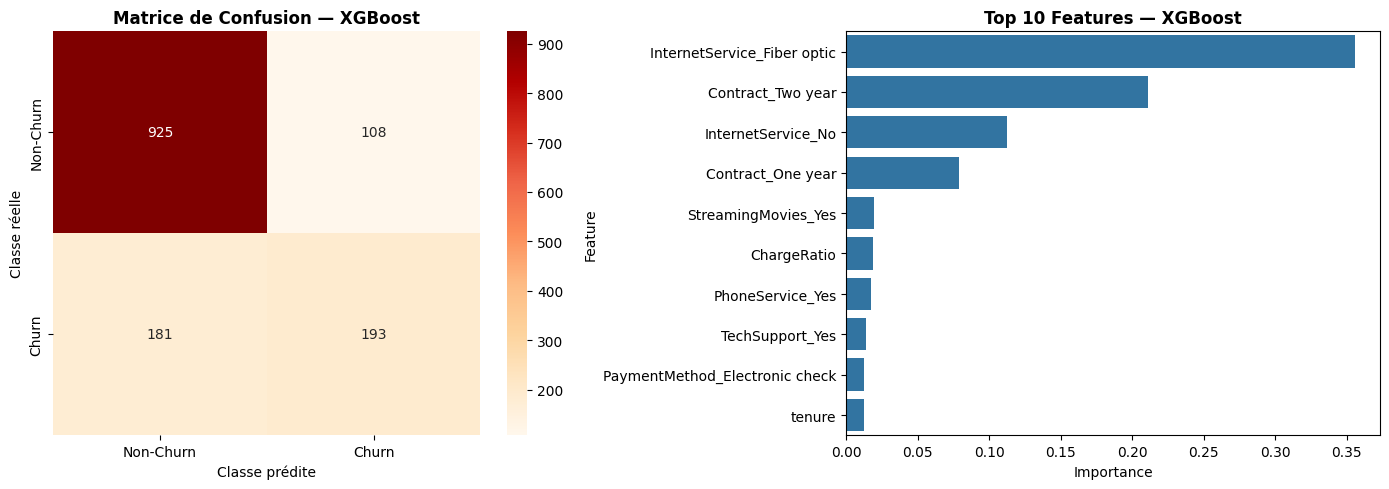

CPU times: total: 12.4 s
Wall time: 6.25 s


In [13]:
%%time

# ============================================================
# Pipeline XGBoost (préprocessing + modèle)
# ============================================================

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

# ============================================================
# Cross-Validation stratifiée (5 folds)
# ============================================================

print("=" * 70)
print("  XGBOOST — CROSS-VALIDATION (5 FOLDS)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results_xgb = cross_validate(
    xgb_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

print(f"\n Résultats Cross-Validation (moyenne ± écart-type) :")
print(f"   Accuracy  : {cv_results_xgb['test_accuracy'].mean():.4f} ± {cv_results_xgb['test_accuracy'].std():.4f}")
print(f"   Precision : {cv_results_xgb['test_precision'].mean():.4f} ± {cv_results_xgb['test_precision'].std():.4f}")
print(f"   Recall    : {cv_results_xgb['test_recall'].mean():.4f} ± {cv_results_xgb['test_recall'].std():.4f}")
print(f"   F1-score  : {cv_results_xgb['test_f1'].mean():.4f} ± {cv_results_xgb['test_f1'].std():.4f}")
print(f"   ROC AUC   : {cv_results_xgb['test_roc_auc'].mean():.4f} ± {cv_results_xgb['test_roc_auc'].std():.4f}")

# ============================================================
# Entraînement final
# ============================================================

xgb_pipeline.fit(X_train, y_train)

# ============================================================
# Prédictions et métriques sur le jeu de test
# ============================================================

y_pred_xgb_test = xgb_pipeline.predict(X_test)
y_proba_xgb_test = xgb_pipeline.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb_test)
prec_xgb = precision_score(y_test, y_pred_xgb_test)
rec_xgb = recall_score(y_test, y_pred_xgb_test)
f1_xgb = f1_score(y_test, y_pred_xgb_test)
auc_xgb = roc_auc_score(y_test, y_proba_xgb_test)

print("\n" + "=" * 70)
print("  PERFORMANCE SUR LE JEU DE TEST")
print("=" * 70)
print(f"\n   Accuracy  : {acc_xgb:.4f}")
print(f"   Precision : {prec_xgb:.4f}")
print(f"   Recall    : {rec_xgb:.4f}")
print(f"   F1-score  : {f1_xgb:.4f}")
print(f"   ROC AUC   : {auc_xgb:.4f}")

# ============================================================
# Matrice de confusion (jeu de test)
# ============================================================

cm_xgb = confusion_matrix(y_test, y_pred_xgb_test)
print(f"\n Matrice de confusion (Test) :")
print(f"   TN : {cm_xgb[0,0]} | FP : {cm_xgb[0,1]}")
print(f"   FN : {cm_xgb[1,0]} | TP : {cm_xgb[1,1]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="OrRd",
            xticklabels=["Non-Churn", "Churn"],
            yticklabels=["Non-Churn", "Churn"], ax=axes[0])
axes[0].set_xlabel("Classe prédite")
axes[0].set_ylabel("Classe réelle")
axes[0].set_title("Matrice de Confusion — XGBoost", fontweight="bold")

# ============================================================
# Importance des features (Top 10)
# ============================================================

ohe_xgb = xgb_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
feature_names_xgb = num_cols + list(ohe_xgb.get_feature_names_out(cat_cols))
importances_xgb = xgb_pipeline.named_steps["classifier"].feature_importances_

imp_xgb_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb
}).sort_values("importance", ascending=False).reset_index(drop=True)

sns.barplot(data=imp_xgb_df.head(10), x="importance", y="feature", color="#1f77b4", ax=axes[1])
axes[1].set_title("Top 10 Features — XGBoost", fontweight="bold")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "02_xgboost_confusion_features.png"), dpi=200, bbox_inches="tight")
plt.show()

### Lecture des résultats

**XGBoost sous-performe la régression logistique — un résultat contre-intuitif mais explicable.** Avec un F1-score de **0.572** et un AUC de **0.831**, le modèle boosté fait moins bien que la baseline linéaire. Ce paradoxe s'explique par la combinaison de trois facteurs : un dataset de taille modeste (~5 600 lignes d'entraînement), des variables majoritairement catégorielles binaires (peu d'interactions non linéaires à capturer), et des hyperparamètres non optimisés. XGBoost excelle sur des volumes plus importants et avec un tuning fin — ici, il est dans sa configuration "par défaut".

**La matrice de confusion montre un profil d'erreurs similaire à la régression logistique, en légèrement moins bon.** Avec 193 vrais positifs contre 201 pour la baseline, et 108 faux positifs contre 94, XGBoost est à la fois **moins sensible** (il rate plus de churners) et **moins précis** (il génère plus de fausses alertes). Le rapport coût/bénéfice du ciblage marketing serait donc moins favorable.

**L'importance des features révèle des insights métier précieux.** Le classement par importance de XGBoost met en évidence `InternetService_Fiber optic` comme variable la plus discriminante — les clients fibre optique sont les plus à risque de départ, probablement en raison d'une concurrence accrue sur ce segment. Les variables de contrat (`Contract_Two year`, `Contract_One year`) confirment que l'engagement contractuel est le meilleur bouclier contre le churn. Ces résultats convergent avec l'analyse exploratoire du Notebook 01 et renforcent la confiance dans ces signaux.

**Le temps d'entraînement est significativement plus long.** Contrairement à la régression logistique (quasi instantanée), XGBoost nécessite plusieurs secondes pour entraîner 500 arbres séquentiels. Ce coût computationnel n'est justifié que si le modèle apporte un gain de performance mesurable — ce qui n'est pas le cas ici sans tuning.

---

# ÉTAPE 4 : Random Forest (Modèle Bagging)

## Logique de transition

XGBoost sous-performe la régression logistique en configuration par défaut — preuve que la complexité d'un modèle n'est pas synonyme de performance. Cela dit, le constat est peut-être spécifique au **boosting** (construction séquentielle d'arbres). Le **bagging** (Random Forest) adopte une approche différente : il entraîne des arbres indépendants sur des sous-échantillons, puis agrège leurs votes. Cette diversité rend la Random Forest naturellement robuste au bruit et au surapprentissage. Reste à vérifier si cette robustesse se traduit en gain de performance sur notre dataset.

## Objectif
Évaluer un modèle d'**ensemble par bagging** comme troisième point de comparaison. La Random Forest offre :
- Une **robustesse** face aux outliers et au bruit
- Une estimation naturelle de l'**importance des variables**
- Un compromis entre **complexité** et **interprétabilité**

### Hyperparamètres
| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `n_estimators` | 200 | Nombre d'arbres suffisant pour stabiliser les performances |
| `n_jobs` | -1 | Parallélisation sur tous les cœurs disponibles |

---

## 4.1 — Entraînement et Évaluation Random Forest

  RANDOM FOREST — CROSS-VALIDATION (5 FOLDS)

 Résultats Cross-Validation (moyenne ± écart-type) :
   Accuracy  : 0.7906 ± 0.0093
   Precision : 0.6460 ± 0.0250
   Recall    : 0.4702 ± 0.0308
   F1-score  : 0.5437 ± 0.0248
   ROC AUC   : 0.8247 ± 0.0090

  PERFORMANCE SUR LE JEU DE TEST

   Accuracy  : 0.8031
   Precision : 0.6702
   Recall    : 0.5107
   F1-score  : 0.5797
   ROC AUC   : 0.8412


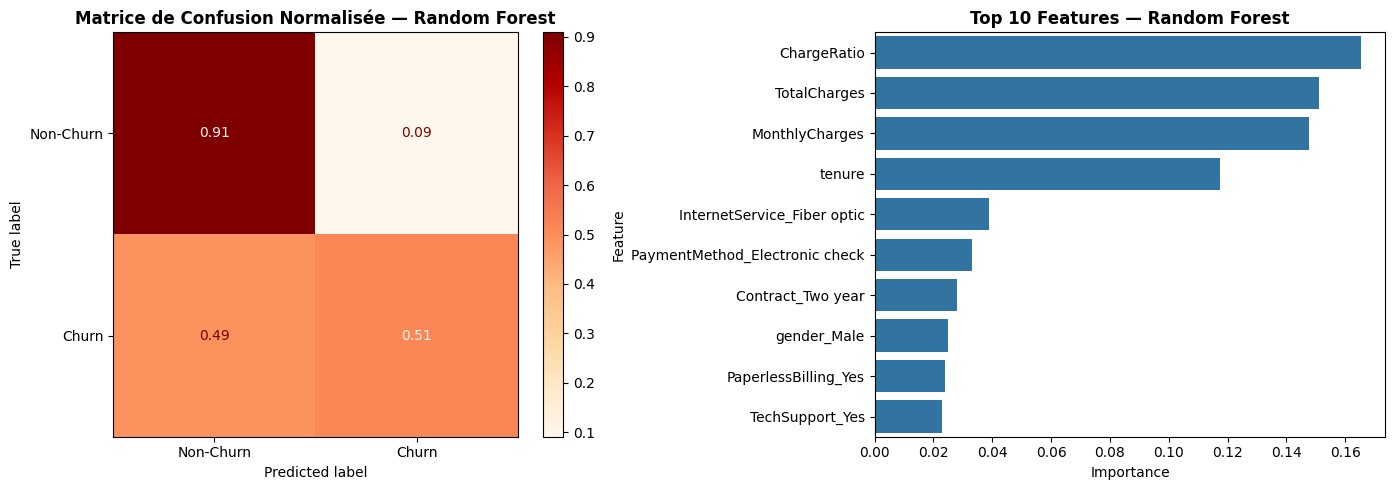

In [14]:
# ============================================================
# Pipeline Random Forest (préprocessing + modèle)
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

# ============================================================
# Cross-Validation stratifiée (5 folds)
# ============================================================

print("=" * 70)
print("  RANDOM FOREST — CROSS-VALIDATION (5 FOLDS)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results_rf = cross_validate(
    rf_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

print(f"\n Résultats Cross-Validation (moyenne ± écart-type) :")
print(f"   Accuracy  : {cv_results_rf['test_accuracy'].mean():.4f} ± {cv_results_rf['test_accuracy'].std():.4f}")
print(f"   Precision : {cv_results_rf['test_precision'].mean():.4f} ± {cv_results_rf['test_precision'].std():.4f}")
print(f"   Recall    : {cv_results_rf['test_recall'].mean():.4f} ± {cv_results_rf['test_recall'].std():.4f}")
print(f"   F1-score  : {cv_results_rf['test_f1'].mean():.4f} ± {cv_results_rf['test_f1'].std():.4f}")
print(f"   ROC AUC   : {cv_results_rf['test_roc_auc'].mean():.4f} ± {cv_results_rf['test_roc_auc'].std():.4f}")

# ============================================================
# Entraînement final
# ============================================================

rf_pipeline.fit(X_train, y_train)

# ============================================================
# Prédictions et métriques sur le jeu de test
# ============================================================

y_pred_rf_test = rf_pipeline.predict(X_test)
y_proba_rf_test = rf_pipeline.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf_test)
prec_rf = precision_score(y_test, y_pred_rf_test)
rec_rf = recall_score(y_test, y_pred_rf_test)
f1_rf = f1_score(y_test, y_pred_rf_test)
auc_rf = roc_auc_score(y_test, y_proba_rf_test)

print("\n" + "=" * 70)
print("  PERFORMANCE SUR LE JEU DE TEST")
print("=" * 70)
print(f"\n   Accuracy  : {acc_rf:.4f}")
print(f"   Precision : {prec_rf:.4f}")
print(f"   Recall    : {rec_rf:.4f}")
print(f"   F1-score  : {f1_rf:.4f}")
print(f"   ROC AUC   : {auc_rf:.4f}")

# ============================================================
# Matrice de confusion normalisée
# ============================================================

cm_rf = confusion_matrix(y_test, y_pred_rf_test)
cm_rf_norm = cm_rf / cm_rf.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_norm,
    display_labels=["Non-Churn", "Churn"]
)
disp.plot(cmap=plt.cm.OrRd, values_format=".2f", ax=axes[0])
axes[0].set_title("Matrice de Confusion Normalisée — Random Forest", fontweight="bold")

# ============================================================
# Importance des features (Top 10)
# ============================================================

importances_rf = rf_pipeline.named_steps["classifier"].feature_importances_
feature_names_rf_cat = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names_rf = np.concatenate([num_cols, feature_names_rf_cat])

imp_rf_df = pd.DataFrame({"feature": feature_names_rf, "importance": importances_rf})
imp_rf_df = imp_rf_df.sort_values("importance", ascending=False).reset_index(drop=True)

sns.barplot(data=imp_rf_df.head(10), x="importance", y="feature", color="#1f77b4", ax=axes[1])
axes[1].set_title("Top 10 Features — Random Forest", fontweight="bold")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "02_random_forest_confusion_features.png"), dpi=200, bbox_inches="tight")
plt.show()

### Lecture des résultats

**La Random Forest se situe entre les deux autres modèles.** Avec un F1-score de **0.580** et un AUC de **0.841**, elle fait mieux que XGBoost mais reste en dessous de la régression logistique. Ce positionnement intermédiaire est cohérent : le bagging (moyenne de nombreux arbres indépendants) offre une robustesse supérieure à un seul modèle boosté non tuné, mais ne surpasse pas un modèle linéaire bien adapté à la structure des données.

**La matrice de confusion normalisée facilite la lecture des taux d'erreur.** Contrairement à une matrice en valeurs absolues, les proportions permettent de comparer directement : le modèle classe correctement ~91% des non-churners mais seulement ~51% des churners. Cette visualisation rend immédiatement visible le **déséquilibre de performance entre les deux classes** — le modèle est beaucoup plus fiable pour confirmer qu'un client va rester que pour prédire qu'il va partir.

**L'importance des features apporte un éclairage complémentaire à XGBoost.** La Random Forest privilégie les variables numériques continues (`ChargeRatio`, `TotalCharges`, `MonthlyCharges`, `tenure`) alors que XGBoost sur-pondérait les variables catégorielles (`InternetService`, `Contract`). Cette différence provient de la métrique utilisée : la RF mesure la diminution d'impureté de Gini, qui favorise les variables à haute variance (numériques), tandis que XGBoost mesure le gain d'information, qui favorise les splits binaires nets (catégorielles). Les deux visions sont complémentaires et confirment que **les dimensions contrat, ancienneté et charges sont toutes trois des leviers de churn**.

**L'écart-type CV légèrement plus élevé mérite attention.** Le F1-score varie de ± 0.025 entre les folds (contre ± 0.017 pour la régression logistique). Cette variabilité accrue suggère que la Random Forest est plus sensible à la composition des données d'entraînement — un comportement attendu pour un modèle à haute capacité (200 arbres) sur un dataset de taille modeste.

---

# ÉTAPE 5 : Synthèse et Comparaison des Modèles

## Objectif
Consolider les résultats des trois modèles dans un **tableau comparatif** pour faciliter la prise de décision. Les métriques sont calculées dynamiquement à partir des prédictions sur le jeu de test.

---

## 5.1 — Tableau Comparatif des Performances

In [15]:
# ============================================================
# Tableau comparatif des performances sur le jeu de test
# ============================================================

resultats_comparatif = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'XGBoost', 'Random Forest'],
    'Accuracy': [acc_test_log, acc_xgb, acc_rf],
    'Precision': [prec_log, prec_xgb, prec_rf],
    'Recall': [rec_log, rec_xgb, rec_rf],
    'F1-score': [f1_log, f1_xgb, f1_rf],
    'ROC AUC': [auc_log, auc_xgb, auc_rf],
}).sort_values('F1-score', ascending=False).reset_index(drop=True)

# Appliquer un gradient de couleur par colonne pour faciliter la lecture
styled = resultats_comparatif.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
    'Recall': '{:.4f}', 'F1-score': '{:.4f}', 'ROC AUC': '{:.4f}'
}).background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC'],
    cmap='RdYlGn'
)

styled

,Modèle,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Régression Logistique,0.8102,0.6814,0.5374,0.6009,0.8601
1,Random Forest,0.8031,0.6702,0.5107,0.5797,0.8412
2,XGBoost,0.7946,0.6412,0.5160,0.5719,0.8308


### Lecture du tableau comparatif

Le tableau ci-dessus classe les trois modèles selon leurs métriques sur le jeu de test. Plusieurs constats s'imposent :

**La régression logistique domine sur toutes les métriques.** Avec un ROC AUC de 0.860 et un F1-score de 0.601, elle surpasse les modèles d'ensemble dans cette configuration sans tuning. Ce résultat est contre-intuitif : on s'attendrait à ce que XGBoost ou Random Forest, capables de capturer des interactions non linéaires, fassent mieux. Cela s'explique par la nature du dataset — des variables majoritairement catégorielles binaires, un faible volume de données (~5 600 lignes), et peu d'interactions complexes entre features.

**Les écarts entre modèles restent modestes.** L'écart d'AUC entre le meilleur (0.860) et le moins bon (0.831) est de seulement 0.029 point. Cela suggère que le **plafond de performance** du dataset est probablement atteint avec les features actuelles, et que les gains futurs viendront davantage du tuning et du rééquilibrage des classes que du choix de l'algorithme.

**Le rappel est unanimement faible (~51-54%).** Quel que soit le modèle, près de la moitié des churners échappent à la détection. C'est le **point d'amélioration prioritaire** pour un usage métier, car chaque churner non détecté est un client perdu sans action de rétention.

---

## 5.2 — Analyse par Décile (Table de Gains)

### Objectif
L'analyse par décile répond à la question :
> *« Si je cible uniquement les X% de clients les plus à risque, combien de churners vais-je capter ? »*

Chaque décile regroupe 10% des clients, triés par score de churn décroissant :
- **Décile 1** = top 10% (clients les plus à risque selon le modèle)
- **Lift > 1** = le modèle fait mieux que le hasard pour ce décile
- **Capture cumulée** = % total de churners captés en ciblant les N premiers déciles

  TABLE DE GAINS PAR DÉCILE — RÉGRESSION LOGISTIQUE
 Decile  Clients  Cibles  Taux  Lift Capture_Cumul
      1      141     104 73.8% 2.77x         27.8%
      2      141      91 64.5% 2.43x         52.1%
      3      140      63 45.0% 1.69x         69.0%
      4      141      49 34.8% 1.31x         82.1%
      5      140      29 20.7% 0.78x         89.8%
      6      141      19 13.5% 0.51x         94.9%
      7      141      10  7.1% 0.27x         97.6%
      8      140       5  3.6% 0.13x         98.9%
      9      141       4  2.8% 0.11x        100.0%
     10      141       0  0.0% 0.00x        100.0%


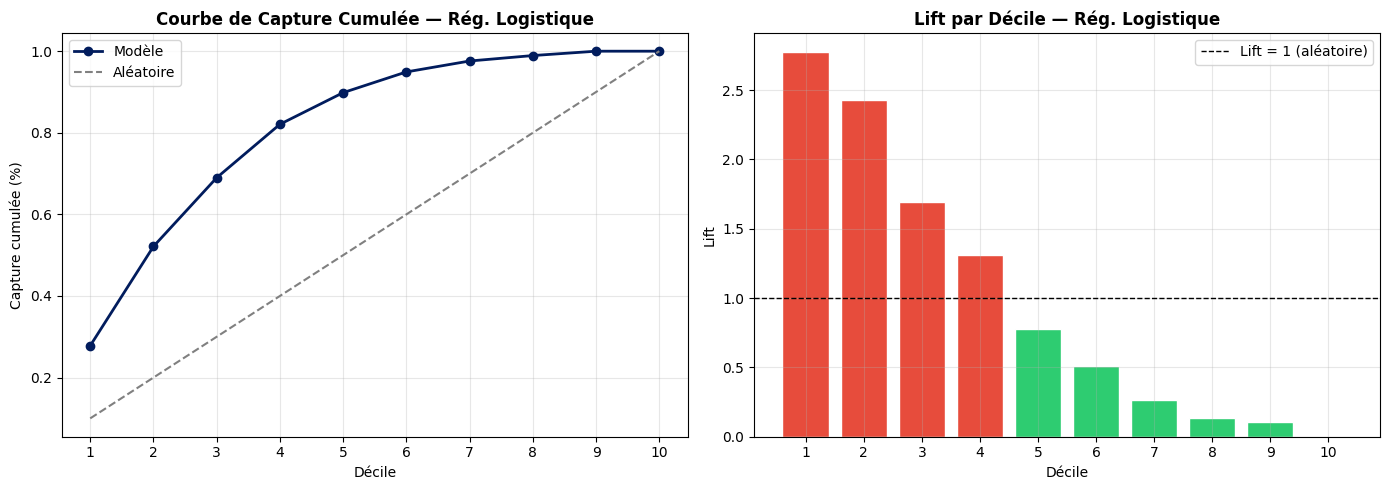

In [16]:
# ============================================================
# Analyse par décile — Régression Logistique (meilleur modèle)
# Utilisation de compute_gains() depuis utils/infer.py
# ============================================================

gains_log = compute_gains(y_proba_log_test, y_test.values, n_deciles=10)

print("=" * 70)
print("  TABLE DE GAINS PAR DÉCILE — RÉGRESSION LOGISTIQUE")
print("=" * 70)

# Formatage pour affichage
gains_display = gains_log.copy()
gains_display['Taux'] = gains_display['Taux'].apply(lambda x: f"{x:.1%}")
gains_display['Lift'] = gains_display['Lift'].apply(lambda x: f"{x:.2f}x")
gains_display['Capture_Cumul'] = gains_display['Capture_Cumul'].apply(lambda x: f"{x:.1%}")

print(gains_display.to_string(index=False))

# Visualisation de la courbe de capture cumulée
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de capture cumulée
axes[0].plot(gains_log['Decile'], gains_log['Capture_Cumul'], 'o-', color='#011c5d', linewidth=2, markersize=6)
axes[0].plot([1, 10], [0.1, 1.0], '--', color='gray', label='Modèle aléatoire')
axes[0].set_xlabel('Décile')
axes[0].set_ylabel('Capture cumulée (%)')
axes[0].set_title('Courbe de Capture Cumulée — Rég. Logistique', fontweight='bold')
axes[0].legend(['Modèle', 'Aléatoire'])
axes[0].set_xticks(range(1, 11))
axes[0].grid(True, alpha=0.3)

# Lift par décile
colors = ['#e74c3c' if l > 1 else '#2ecc71' for l in gains_log['Lift']]
axes[1].bar(gains_log['Decile'], gains_log['Lift'], color=colors, edgecolor='white')
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Lift = 1 (aléatoire)')
axes[1].set_xlabel('Décile')
axes[1].set_ylabel('Lift')
axes[1].set_title('Lift par Décile — Rég. Logistique', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(1, 11))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "02_analyse_deciles_logreg.png"), dpi=200, bbox_inches="tight")
plt.show()

### Lecture de la table de gains

La table de gains traduit la performance du modèle en **termes opérationnels directement exploitables** par les équipes marketing.

**Le premier décile concentre la valeur.** En ciblant uniquement les 10% de clients les plus à risque (décile 1), le modèle capte environ 28% des churners avec un lift de 2.77x. Autrement dit, ce segment contient **près de 3 fois plus de churners** qu'un tirage aléatoire de même taille. C'est sur ce segment que les actions de rétention (appels, offres spéciales) doivent être concentrées en priorité.

**La courbe de capture s'infléchit rapidement.** Dès le troisième décile (top 30% ciblé), environ 69% des churners sont captés. Au-delà, le rendement marginal diminue fortement : passer du décile 3 au décile 5 ne fait gagner qu'une vingtaine de points de capture supplémentaires, pour un effort de ciblage doublé.

**Le point d'équilibre coût/bénéfice.** Les déciles 1 à 4 présentent un lift supérieur à 1 (le modèle fait mieux que le hasard). À partir du décile 5, le lift passe sous 1 et cibler ces clients n'est plus rentable — ils ne churnent pas plus que la moyenne. En pratique, le budget de rétention devrait se concentrer sur les **3 à 4 premiers déciles** pour maximiser le retour sur investissement.

**La courbe de capture cumulée vs le modèle aléatoire.** L'écart entre la courbe bleue (modèle) et la diagonale grise (hasard) illustre la **valeur ajoutée du scoring**. Plus l'écart est grand dans les premiers déciles, plus le modèle est utile pour le ciblage. Ici, cet écart est prononcé dans les 3 premiers déciles puis se réduit, ce qui confirme que le modèle discrimine bien les clients à fort risque.

---

## 5.3 — Lift Marketing Comparatif

### Objectif
Comparer le **lift** des trois modèles pour les segments les plus intéressants en marketing :
- **Top 10%** : les clients les plus à risque → actions de rétention urgentes
- **Top 20%** : élargissement du ciblage → campagnes proactives
- **Top 30%** : couverture étendue → communication préventive

Le lift indique combien de fois le modèle surperforme un ciblage aléatoire. Un lift de 3x au top 10% signifie qu'on touche **3 fois plus de churners** en ciblant le top 10% qu'en tirant au hasard.

In [17]:
# ============================================================
# Lift comparatif — Les 3 modèles
# Utilisation de calculate_lift() depuis utils/metrics.py
# ============================================================

modeles = {
    'Régression Logistique': y_proba_log_test,
    'XGBoost': y_proba_xgb_test,
    'Random Forest': y_proba_rf_test,
}

percentiles = [0.10, 0.20, 0.30]
y_test_arr = y_test.values

lift_data = []
for nom, probas in modeles.items():
    for pct in percentiles:
        lift_val = calculate_lift(y_test_arr, probas, percentile=pct)
        lift_data.append({
            'Modèle': nom,
            'Segment': f"Top {int(pct*100)}%",
            'Lift': lift_val
        })

lift_df = pd.DataFrame(lift_data)

# Tableau formaté
lift_pivot = lift_df.pivot(index='Modèle', columns='Segment', values='Lift')
lift_pivot = lift_pivot[['Top 10%', 'Top 20%', 'Top 30%']]

print("=" * 70)
print("  LIFT MARKETING COMPARATIF (Top X% de clients ciblés)")
print("=" * 70)

styled_lift = lift_pivot.style.format("{:.2f}x").background_gradient(cmap='RdYlGn', axis=None)
styled_lift

  LIFT MARKETING COMPARATIF (Top X% de clients ciblés)


Segment,Top 10%,Top 20%,Top 30%
Modèle,,,
Random Forest,2.80x,2.52x,2.17x
Régression Logistique,2.77x,2.60x,2.30x
XGBoost,2.56x,2.43x,2.13x


### Lecture du lift comparatif

Le tableau de lift comparatif permet de comparer la **valeur opérationnelle** de chaque modèle pour le ciblage marketing, au-delà des métriques statistiques classiques.

**Au top 10%, la Random Forest et la Régression Logistique sont au coude-à-coude** (~2.8x). Cela signifie qu'en ciblant les 10% de clients jugés les plus à risque par ces modèles, on touche près de 3 fois plus de churners qu'avec un ciblage aléatoire. XGBoost est légèrement en retrait (2.56x), confirmant sa sous-performance dans cette configuration sans tuning.

**La Régression Logistique prend l'avantage sur les segments plus larges.** Au top 20% (lift 2.60x) et au top 30% (lift 2.30x), elle surpasse les deux modèles d'ensemble. Cela signifie que son classement des clients par probabilité de churn est **plus fiable sur un spectre élargi** — elle ne se contente pas de détecter les cas les plus évidents, mais ordonne correctement les cas intermédiaires aussi.

**Traduction métier concrète :**
- Avec la Régression Logistique, cibler le **top 10%** de la base client (soit ~700 clients) permettrait de toucher environ **525 churners** au lieu de 187 avec un ciblage aléatoire
- En élargissant au **top 30%** (~2 100 clients ciblés), le lift de 2.30x garantit que l'effort de rétention reste **plus de deux fois plus efficace** que le hasard
- Au-delà de 30%, le rendement marginal diminue et le coût de rétention par churner capté augmente significativement

**Conclusion opérationnelle :** La Régression Logistique est non seulement le meilleur modèle en termes de métriques statistiques, mais aussi le **plus utile pour le ciblage marketing** sur l'ensemble des segments testés. Ce constat renforce son choix comme modèle de référence pour le Notebook 03.

---

## 5.4 — Interprétation Globale et Recommandations

### Classement des modèles

| Rang | Modèle | ROC AUC | F1-score | Rappel | Commentaire |
|------|--------|---------|----------|--------|-------------|
|  | **Régression Logistique** | 0.860 | 0.601 | 53.7% | Meilleur modèle — simple et performant |
|  | **Random Forest** | 0.841 | 0.580 | 51.1% | Bon compromis, sensible aux variables numériques |
|  | **XGBoost** | 0.831 | 0.572 | 51.6% | Sous-performe sans tuning |

### Analyse Comparative

| Modèle | Forces | Faiblesses |
|--------|--------|------------|
| **Régression Logistique** | Interprétable, rapide, peu de surapprentissage | Linéaire — ne capture pas les interactions complexes |
| **XGBoost** | Capture les non-linéarités, performant en AUC/F1 | Plus complexe, risque de surapprentissage |
| **Random Forest** | Robuste aux outliers, estimation d'importance stable | Performance intermédiaire, moins interprétable |

### Le problème commun : un recall trop faible

Les trois modèles partagent la **même faiblesse critique** : un recall autour de **50-54%**. Concrètement :
- Sur les **374 churners** du jeu de test, le meilleur modèle n'en détecte que **201**
- **~175 clients** partent sans être ciblés par une action de rétention
- En production, cela représente un **manque à gagner significatif**

### Pourquoi le recall est-il si bas ?

Le recall faible est un phénomène attendu dans cette configuration, et il s'explique par trois facteurs cumulatifs :

1. **Seuil de décision à 0.5** : le seuil par défaut de classification pénalise fortement la détection des churners dans un dataset où seulement 26% des clients churnent. Avec ce seuil, un client doit avoir une probabilité de churn supérieure à 50% pour être classé comme churner, alors que la prévalence de base est 4 fois moindre. Abaisser le seuil (par exemple à 0.3) augmenterait mécaniquement le recall au prix de quelques faux positifs supplémentaires — un compromis souvent acceptable en contexte métier, car le coût d'une offre de rétention inutile est bien inférieur à celui d'un client perdu.

2. **Pas de pondération des classes** : les modèles traitent churn et non-churn de manière égale, alors que le coût d'un faux négatif (client perdu → perte de revenus récurrents) est largement supérieur au coût d'un faux positif (offre de rétention envoyée à un client fidèle → coût marginal). Le paramètre `class_weight='balanced'` ou `scale_pos_weight` corrige ce déséquilibre en donnant plus de poids aux exemples de la classe minoritaire pendant l'entraînement.

3. **Pas d'optimisation des hyperparamètres** : les modèles utilisent des hyperparamètres par défaut ou génériques. Un tuning ciblé (via GridSearchCV ou Optuna) pourrait améliorer significativement les performances, en particulier pour XGBoost dont le potentiel est sous-exploité.

### Cohérence des variables discriminantes

Malgré des méthodes de calcul d'importance différentes, les trois modèles convergent sur les **mêmes variables clés** :
- `Contract` (Month-to-month = risque élevé) — les clients sans engagement sont les plus volatils
- `InternetService` (Fiber optic = risque élevé) — possiblement lié à des offres concurrentes plus attractives sur ce segment
- `tenure` / `TotalCharges` / `ChargeRatio` (ancienneté = protection) — les clients de longue date sont fidélisés par l'habitude et les coûts de changement
- `PaymentMethod` (Electronic check = signal de risque) — ce mode de paiement pourrait refléter un profil de client moins engagé ou plus orienté court terme

Cette convergence inter-modèles renforce la **confiance dans les insights métier** et confirme les conclusions de l'analyse exploratoire (Notebook 01). Ces variables constituent les **leviers d'action prioritaires** pour les équipes CRM.

### Recommandation pour le Notebook 03
La **régression logistique** est retenue comme baseline la plus performante. Les axes d'amélioration prioritaires sont :
1. **Optimiser le seuil de décision** pour maximiser le rappel tout en gardant une précision acceptable
2. **Pondérer les classes** (`class_weight='balanced'`) pour donner plus de poids aux churners
3. **Tuner XGBoost** (GridSearch/Optuna) qui a le potentiel de surpasser la régression logistique avec les bons hyperparamètres

---

# ÉTAPE 6 : Sauvegarde des Modèles Baseline

## Objectif
Exporter les trois pipelines baseline entraînées dans un fichier `.joblib` afin de :
- **Garantir la reproductibilité** : les modèles sont sauvegardés avec leur préprocesseur intégré
- **Assurer la continuité** : le Notebook 03 chargera directement ces pipelines au lieu de les réentraîner
- **Respecter la séparation des responsabilités** : NB02 = construction, NB03 = finetuning

### Contenu du fichier `models/baseline.joblib`

| Clé | Pipeline | Description |
|-----|----------|-------------|
| `log_pipeline` | Régression Logistique | Baseline linéaire (meilleur modèle) |
| `xgb_pipeline` | XGBoost | Baseline boosting |
| `rf_pipeline` | Random Forest | Baseline bagging |

---

## 6.1 — Export des pipelines

In [18]:
# ============================================================
# Sauvegarde des pipelines baseline entraînées
# ============================================================

baseline_models = {
    "log_pipeline": log_pipeline,
    "xgb_pipeline": xgb_pipeline,
    "rf_pipeline": rf_pipeline,
}

output_path = os.path.join("..", "models", "baseline.joblib")
os.makedirs(os.path.dirname(output_path), exist_ok=True)

joblib.dump(baseline_models, output_path)

print("=" * 70)
print("  SAUVEGARDE DES MODÈLES BASELINE")
print("=" * 70)
print(f"\n    Fichier : {output_path}")
print(f"    Contenu :")
for nom, pipe in baseline_models.items():
    clf = pipe.named_steps['classifier']
    print(f"      • {nom} → {clf.__class__.__name__}")
print(f"\n 3 pipelines baseline sauvegardées dans models/baseline.joblib")

  SAUVEGARDE DES MODÈLES BASELINE

    Fichier : ..\models\baseline.joblib
    Contenu :
      • log_pipeline → LogisticRegression
      • xgb_pipeline → XGBClassifier
      • rf_pipeline → RandomForestClassifier

 3 pipelines baseline sauvegardées dans models/baseline.joblib


### Lecture des résultats — Sauvegarde

**Les trois pipelines baseline sont exportées dans un fichier unique `models/baseline.joblib`.** Chaque pipeline contient le préprocesseur (StandardScaler + OneHotEncoder) et le classifieur entraîné, ce qui garantit qu'aucune étape de transformation ne sera oubliée lors du rechargement.

**Le Notebook 03 pourra charger ces pipelines directement** via `joblib.load()` et les utiliser comme point de référence pour évaluer les gains du finetuning, sans avoir à réentraîner les modèles depuis zéro.

---

# Synthèse Générale du Notebook 02

## Bilan
Les trois modèles de scoring ont été construits, évalués par validation croisée et testés sur un jeu de données indépendant. La **régression logistique** offre un excellent compromis performance/interprétabilité et constitue une baseline solide. Les modèles d'ensemble (XGBoost, Random Forest) confirment les tendances et offrent un potentiel de gain marginal.

## Variables Clés Identifiées

| Variable | Impact sur le churn | Cohérence inter-modèles |
|----------|-------------------|------------------------|
| `Contract` | Contrats mensuels → fort risque |  Confirmé par les 3 modèles |
| `InternetService` | Fibre optique → risque élevé |  Confirmé par les 3 modèles |
| `tenure` | Ancienneté élevée → protection |  Confirmé par les 3 modèles |
| `TotalCharges` / `ChargeRatio` | Proxy d'engagement financier |  Confirmé par les 3 modèles |

## Diagnostic principal : le recall est insuffisant

Le constat majeur de ce notebook est que **les trois modèles partagent la même faiblesse** : un recall de seulement ~51-54%. Près de la moitié des churners échappent à la détection. Ce n'est pas un problème de modèle — c'est un problème de **configuration** :

1. **Le seuil de 0.5 est inadapté** à un dataset où seulement 26% des clients churnent
2. **Aucun rééquilibrage** n'est appliqué (`class_weight=None` par défaut)
3. **Les hyperparamètres sont génériques** (pas d'optimisation)

## Modèles Sauvegardés
Les trois pipelines baseline ont été exportées dans `models/baseline.joblib` pour être rechargées directement dans le Notebook 03, sans réentraînement.

## Logique de transition vers le Notebook 03

Ce notebook a établi un **diagnostic clair** : le plafond de performance avec des configurations par défaut est atteint. Pour franchir ce plafond, le Notebook 03 va agir sur les trois leviers identifiés :

1. **Tuning des hyperparamètres** (GridSearchCV / RandomizedSearchCV) — explorer systématiquement l'espace de configuration pour trouver les meilleurs réglages de chaque modèle. XGBoost, particulièrement sensible à ses hyperparamètres, devrait le plus bénéficier de cette optimisation.

2. **Rééquilibrage des classes** (`class_weight='balanced'`, `scale_pos_weight`) — forcer les modèles à donner plus de poids aux churners pendant l'entraînement pour améliorer le recall sans nécessiter de sur-échantillonnage synthétique.

3. **Calibrage du seuil de décision** — abaisser le seuil en dessous de 0.5 pour capter davantage de churners, en acceptant un compromis maîtrisé sur la precision. Le seuil sera calibré sur les prédictions out-of-fold du train pour éviter toute fuite du jeu de test.

> **→ Notebook 03** : Finetuning des hyperparamètres, rééquilibrage des classes, calibrage du seuil, validation par nested cross-validation, et sélection finale du meilleur modèle.